###**DIP Practical-8**

**Name:** Yesha Pandya

**Enrollment Number:** 23BT04175

**Div:** 1 **Batch:** C

**Objective:**

To implement and understand SIFT (Scale-Invariant Feature Transform) and HoG (Histogram of Oriented Gradients) feature extraction methods in Digital Image Processing.

**1. Import libraries and image**

In [5]:
#import libraries needed
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from skimage.feature import hog
from skimage import exposure

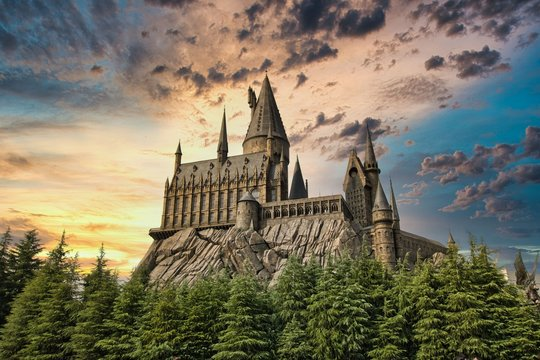

In [6]:
#load and show original image
img=cv2.imread('hogwarts image.jpg')
cv2_imshow(img)

Pre-req: convert image to grayscale

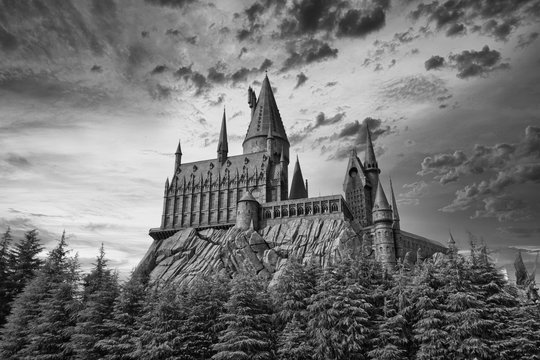

In [7]:
#convert to grayscale
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)

#### **SIFT (Scale-Invariant Feature Transform)**

SIFT is a highly robust algorithm used to detect and describe local features in images. Its primary advantage is that the features extracted are invariant to image scale and rotation; and robust to changes in illumination and noise.

The SIFT algorithm consists of four main steps:

1. **Scale-space Extrema Detection:** Searches over all scales and image locations using a Difference of Gaussian (DoG) function to identify potential interest points.

2. **Keypoint Localization:** Refines the location and scale of candidate keypoints. Points with low contrast or poorly localized edges are rejected.

3. **Orientation Assignment:** Assigns one or more orientations to each keypoint based on local image gradient directions, ensuring rotation invariance.

4. **Keypoint Descriptor:** Computes a highly distinctive local image descriptor (typically a 128-dimensional vector) based on gradient histograms around the keypoint.

Initializing SIFT Detector..
Success! Number of SIFT keypoints detected: 2058
Shape of SIFT descriptors matrix: (2058, 128)

Visualizing SIFT Keypoints:


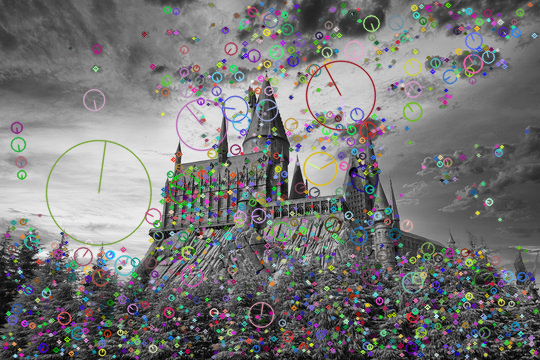

In [10]:
#SIFT Feature Extraction

if img is not None:
    print("Initializing SIFT Detector..")
    #create a SIFT object (Available natively in OpenCV 4.4.0+)
    sift = cv2.SIFT_create()

    #detect keypoints and compute the descriptors
    #the second parameter is a mask (None means we process the whole image)
    keypoints, descriptors = sift.detectAndCompute(gray, None)

    print(f"Success! Number of SIFT keypoints detected: {len(keypoints)}")
    if descriptors is not None:
        print(f"Shape of SIFT descriptors matrix: {descriptors.shape}")

    print("\nVisualizing SIFT Keypoints:")
    #draw keypoints on the image
    #cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS ensures the size of the circle
    #corresponds to the scale of the feature, and the line shows its orientation.
    sift_img = cv2.drawKeypoints(gray, keypoints, img.copy(),
                                 flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    cv2_imshow(sift_img)

#### **HoG (Histogram of Oriented Gradients)**

HoG is a feature descriptor widely used in computer vision for object detection (most famously for pedestrian detection). Instead of finding localized keypoints like SIFT, HoG describes the global shape and structural appearance of an object by analyzing the distribution of intensity gradients (edge directions).

The HoG pipeline involves:

1. **Gradient Computation:** Calculating the horizontal and vertical gradients of the image to find edge magnitude and direction.

2. **Cell Binning:** Dividing the image into small spatial regions called "cells" (e.g., $8*8$ pixels) and accumulating a 1D histogram of gradient directions over the pixels in each cell.

3. **Block Normalization:** Grouping cells into larger "blocks" (e.g., $2*2$ cells) and normalizing the histograms within these blocks to make the descriptor robust to lighting and shadowing changes.

Extracting HoG Features...
Success! Total number of HoG features extracted: 104544

Visualizing HoG Features


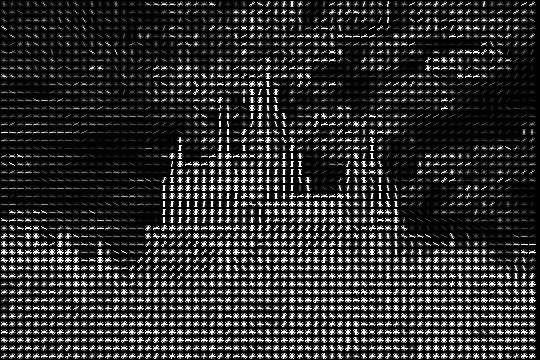

In [13]:
#HoG Feature Extraction

if img is not None:
    print("Extracting HoG Features...")
    '''
    We use skimage.feature.hog here because it conveniently returns an image for visualizing the gradients
    orientations = 9 (number of bins in the histogram)
    pixels_per_cell = (8, 8) (size of the spatial region)
    cells_per_block = (2, 2) (number of cells in each normalization block)
    '''

    features, hog_image = hog(gray,
                              orientations=9,
                              pixels_per_cell=(8, 8),
                              cells_per_block=(2, 2),
                              visualize=True,
                              channel_axis=None) #None because grayscale img is 2D

    print(f"Success! Total number of HoG features extracted: {len(features)}")

    print("\nVisualizing HoG Features")
    #the raw hog_image usually has very low intensity values.
    #we rescale the intensity to make the gradient lines visible.
    hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

    #convert back to an 8-bit image format compatible with OpenCV display
    hog_image_display = (hog_image_rescaled * 255).astype(np.uint8)

    cv2_imshow(hog_image_display)

#### **Conclusion / Observations:**

* SIFT output shows highly localized circles. These represent interest points that are mathematically robust to scale and rotation. SIFT is ideal for image stitching, 3D modeling, and tracking.

* HoG output shows a dense grid of lines. These lines represent the dominant gradient orientations in local grid cells. HoG effectively captures the structural outline of the subjects in the image, making it highly effective for machine learning-based object detection pipelines.